# Home Credit Default Risk Prediction

The bank is deciding whether to approve or reject a loan application.

In credit risk "Default" = the borrower fails to repay the loan as agreed.

There are four possible outcomes:
1. The bank approves the loan and the preson repays: bank earns interest and fees which means profit
2. The bank approves the loan and the person defaults: bank loses part of principal, legal costs, operational costs which means loss
3. The bank rejects the loan for someone who would repay: bank loses potential interest income and opportunity which means loss
4. The bank rejects the loan for someone who would default: bank avoids loss

Our goal: Estimate probability of default well enough to make profitable approval decisions

Decision rule: The loan should be approved if PD (probability of default) < p (derived from expected profit)

Evaluation metrics: expected profit, ROC-AUC (for ranking), Calibration (Brier score)

Expected profit is caluclated using this formula:
(1 - PD) * Revenue - PD * Loss

Using the following parameters:
1. Interest rate (r) = 18%
2. LGD = 60%
3. Loan amount = 30% of annual income

The threshold p becomes: 23%

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = 'Data/application_train.csv'

df = pd.read_csv(path, low_memory=False)
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.memory_usage(deep=True).sum() / 1024**2

np.float64(504.98532581329346)

In [4]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [5]:
target = "TARGET"
df[target].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Data Leakage check

In [6]:
suspects = [c for c in df.columns if any(k in c.upper() for k in ["OVERDUE","DEFAULT","RECOVER","PAST","DUE"])]
suspects[:30], len(suspects)

([], 0)

Data quality check

Types and missing values

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


1. float64 - 65 columns
2. int64 - 41 columns
3. object - 16 columns

In [8]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_MEDI            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
dtype: float64

In [9]:
too_missing = missing[missing>0.6].index.tolist()
len(too_missing)

17

17 columns with too many missing values

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns
card = df[cat_cols].nunique().sort_values(ascending=False)
card.head(20)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64

In [11]:
num_cols = df.select_dtypes(exclude=['object']).columns.drop(target)
df[num_cols].describe().T.sort_values('max', ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
OBS_30_CNT_SOCIAL_CIRCLE,306490.0,1.422245,2.400989,0.0,0.0,0.0,2.0,348.0
OBS_60_CNT_SOCIAL_CIRCLE,306490.0,1.405292,2.379803,0.0,0.0,0.0,2.0,344.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
OWN_CAR_AGE,104582.0,12.061091,11.944812,0.0,5.0,9.0,15.0,91.0


In [12]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[target], random_state=23)

The column DAYS_EMPLOYED seems to contain unreal large values like 365243.

Since looking at the days do determine if they are real or not is hard we will create a new column with year employed

In [13]:
df1 = train_df.copy()
df1['years_employed'] = (df1['DAYS_EMPLOYED']/365).astype(int)

We set a threshold for normal number of years employed which I will set to 80

In [14]:
threshold = 80
df1[df1['years_employed']>threshold]['years_employed'].unique()

array([1000])

In [15]:
df1_by_years_employed = df1['years_employed'].value_counts(normalize=True).reset_index()

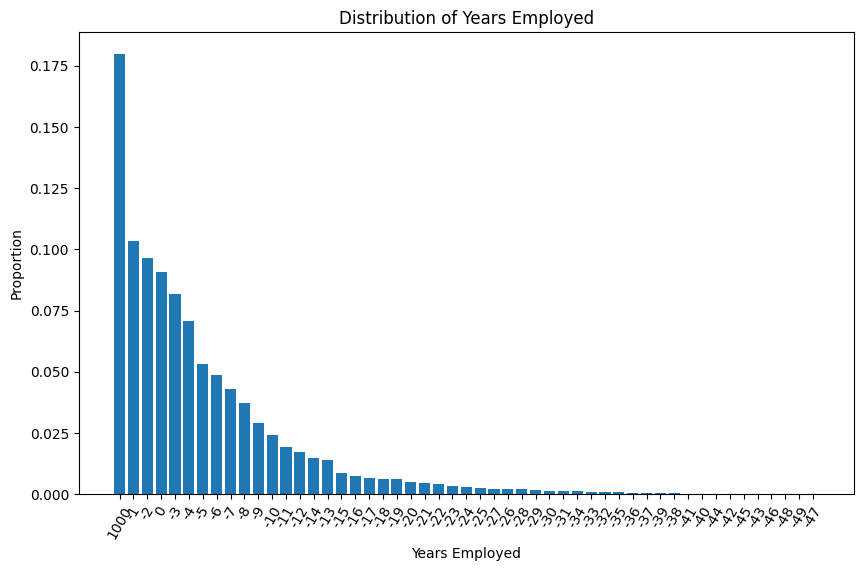

In [16]:
y = df1_by_years_employed['proportion']
x = df1_by_years_employed['years_employed'].astype(str)

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Years Employed')
ax.set_ylabel('Proportion')
ax.set_title('Distribution of Years Employed')
plt.xticks(rotation=60)
plt.show()

In [17]:
df1[df1['years_employed']>threshold]['years_employed'].count()

np.int64(44216)

365243 is a sentinel value

Create anomaly flag

In [18]:
train_df['EMPLOYED_ANOMALY'] = (train_df['DAYS_EMPLOYED']==365243).astype(int)

In [19]:
train_df.loc[train_df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

In [20]:
pd.crosstab(train_df['EMPLOYED_ANOMALY'], train_df[target], normalize='index')

TARGET,0,1
EMPLOYED_ANOMALY,,
0,0.913322,0.086678
1,0.946422,0.053578


Seems like people with the employed anomaly default less

In [21]:
train_df['YEARS_EMPLOYED'] = -train_df['DAYS_EMPLOYED']/365

In [22]:
df1 = train_df.copy()
bins = [0,3,5,10,15,20,25,30,35,40,45,50]
labels = ["0-3","3-5","5-10","10-15","15-20","20-25","25-30","30-35","35-40","40-45","45-50"]
df1['binned_years_employed'] = pd.cut(df1['YEARS_EMPLOYED'],bins=bins,labels=labels)
df1_binned_years = pd.crosstab(df1['binned_years_employed'],df1[target],normalize='index').reset_index()
df1_binned_years

TARGET,binned_years_employed,0,1
0,0-3,0.890026,0.109974
1,3-5,0.902777,0.097223
2,5-10,0.926297,0.073703
3,10-15,0.940496,0.059504
4,15-20,0.952458,0.047542
5,20-25,0.951568,0.048432
6,25-30,0.961194,0.038806
7,30-35,0.963273,0.036727
8,35-40,0.980122,0.019878
9,40-45,0.993750,0.006250


Yes people who are employed longer default less, with the only exception beeing in the ages between 15-20 and 20-25, it seems that people who worked between 15-20 years default less than people who worked between 20-25.

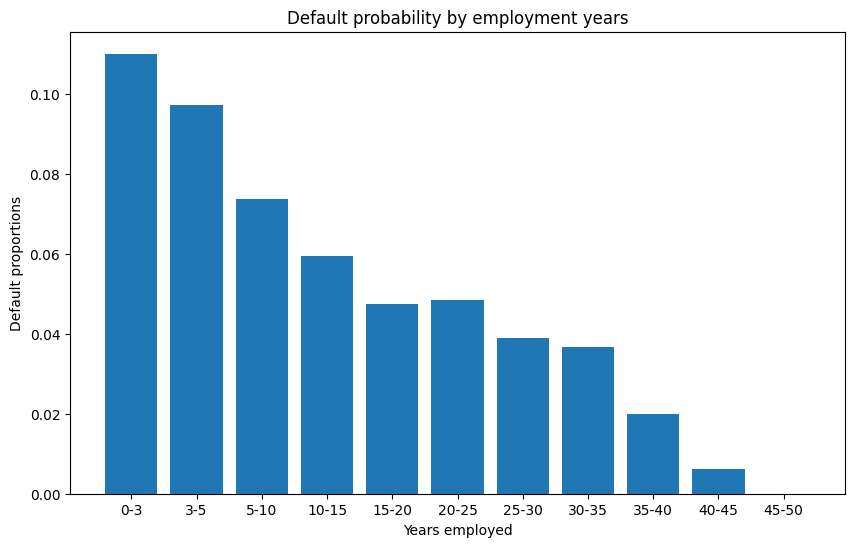

In [23]:
x = df1_binned_years['binned_years_employed']
y = df1_binned_years[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Years employed')
ax.set_ylabel('Default proportions')
ax.set_title('Default probability by employment years')
plt.show()

In [24]:
df1['YEARS_EMPLOYED'].max()

np.float64(49.07397260273972)

In [25]:
train_df['CREDIT_TO_INCOME'] = train_df['AMT_CREDIT'] / train_df['AMT_INCOME_TOTAL']
train_df['ANNUITY_TO_INCOME'] = train_df['AMT_ANNUITY'] / train_df['AMT_INCOME_TOTAL']

In [26]:
df1 = train_df.copy()

In [27]:
df1 = df1[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','CREDIT_TO_INCOME','ANNUITY_TO_INCOME','YEARS_EMPLOYED','EMPLOYED_ANOMALY','TARGET']]

In [28]:
df1.isna().sum()

AMT_INCOME_TOTAL         0
AMT_CREDIT               0
AMT_ANNUITY              9
CREDIT_TO_INCOME         0
ANNUITY_TO_INCOME        9
YEARS_EMPLOYED       44216
EMPLOYED_ANOMALY         0
TARGET                   0
dtype: int64

In [29]:
df1['binned_credit_income_ratio'] = pd.qcut(df1['CREDIT_TO_INCOME'], q=10)
df1['binned_annuity_income_ratio'] = pd.qcut(df1['ANNUITY_TO_INCOME'], q=10)

In [30]:
df1.describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,YEARS_EMPLOYED,EMPLOYED_ANOMALY,TARGET
count,2.460080e+05,2.460080e+05,245999.000000,246008.000000,245999.000000,201792.000000,246008.000000,246008.000000
mean,1.689096e+05,5.986312e+05,27094.128438,3.955604,0.180836,6.526230,0.179734,0.080729
std,2.589069e+05,4.019941e+05,14481.751785,2.691951,0.094676,6.400935,0.383967,0.272419
min,2.565000e+04,4.500000e+04,1615.500000,0.004808,0.000224,-0.000000,0.000000,0.000000
25%,1.125000e+05,2.700000e+05,16506.000000,2.018667,0.114543,2.104110,0.000000,0.000000
50%,1.467000e+05,5.135310e+05,24898.500000,3.259180,0.162618,4.509589,0.000000,0.000000
75%,2.025000e+05,8.086500e+05,34596.000000,5.156138,0.228945,8.693151,0.000000,0.000000
max,1.170000e+08,4.050000e+06,230161.500000,84.736842,1.875965,49.073973,1.000000,1.000000


In [31]:
df1_credit_income_default = pd.crosstab(df1['binned_credit_income_ratio'], df1['TARGET'], normalize='index').reset_index()
df1_annuity_income_default = pd.crosstab(df1['binned_annuity_income_ratio'], df1['TARGET'], normalize='index').reset_index()

In [32]:
df1_credit_income_default

TARGET,binned_credit_income_ratio,0,1
0,"(0.00381, 1.329]",0.932279,0.067721
1,"(1.329, 1.818]",0.923002,0.076998
2,"(1.818, 2.264]",0.919496,0.080504
3,"(2.264, 2.764]",0.907673,0.092327
4,"(2.764, 3.259]",0.913120,0.086880
5,"(3.259, 3.903]",0.906639,0.093361
6,"(3.903, 4.722]",0.913699,0.086301
7,"(4.722, 5.771]",0.921626,0.078374
8,"(5.771, 7.486]",0.925875,0.074125
9,"(7.486, 84.737]",0.929295,0.070705


In [33]:
df1_annuity_income_default

TARGET,binned_annuity_income_ratio,0,1
0,"(-0.000776, 0.0799]",0.929352,0.070648
1,"(0.0799, 0.103]",0.926786,0.073214
2,"(0.103, 0.125]",0.922371,0.077629
3,"(0.125, 0.144]",0.921415,0.078585
4,"(0.144, 0.163]",0.920644,0.079356
5,"(0.163, 0.186]",0.916098,0.083902
6,"(0.186, 0.212]",0.914194,0.085806
7,"(0.212, 0.247]",0.912187,0.087813
8,"(0.247, 0.302]",0.910732,0.089268
9,"(0.302, 1.876]",0.918899,0.081101


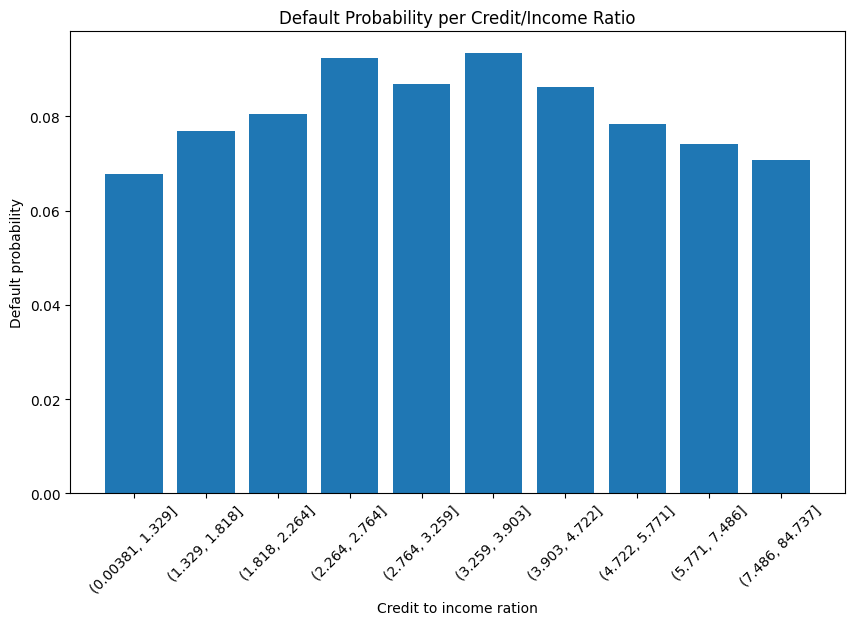

In [34]:
x = df1_credit_income_default['binned_credit_income_ratio'].astype(str)
y = df1_credit_income_default[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Credit to income ration')
ax.set_ylabel('Default probability')
ax.set_title('Default Probability per Credit/Income Ratio')
plt.xticks(rotation=45)
plt.show()

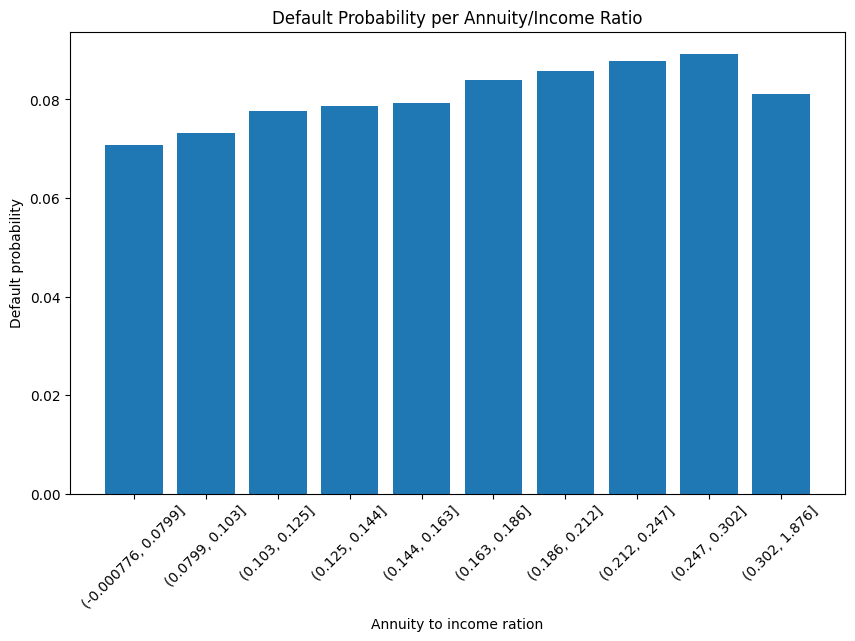

In [35]:
x = df1_annuity_income_default['binned_annuity_income_ratio'].astype(str)
y = df1_annuity_income_default[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Annuity to income ration')
ax.set_ylabel('Default probability')
ax.set_title('Default Probability per Annuity/Income Ratio')
plt.xticks(rotation=45)
plt.show()

In [36]:
df1.groupby('binned_annuity_income_ratio')[target].count()

/tmp/ipykernel_312844/947156242.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('binned_annuity_income_ratio')[target].count()


binned_annuity_income_ratio
(-0.000776, 0.0799]    24601
(0.0799, 0.103]        24599
(0.103, 0.125]         24617
(0.125, 0.144]         24585
(0.144, 0.163]         24598
(0.163, 0.186]         24600
(0.186, 0.212]         24602
(0.212, 0.247]         24609
(0.247, 0.302]         24589
(0.302, 1.876]         24599
Name: TARGET, dtype: int64

In [37]:
df1['ANNUITY_TO_INCOME'].min()

np.float64(0.00022388461538461538)

In [38]:
train_df[['ANNUITY_TO_INCOME', target]].corr()

,ANNUITY_TO_INCOME,TARGET
ANNUITY_TO_INCOME,1.000000,0.014082
TARGET,0.014082,1.000000


In [61]:
binned_annuity_target = train_df.groupby(pd.qcut(train_df['ANNUITY_TO_INCOME'],20,duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/2555184028.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_annuity_target = train_df.groupby(pd.qcut(train_df['ANNUITY_TO_INCOME'],20,duplicates='drop'))[target].mean().reset_index()


In [62]:
binned_annuity_target

,ANNUITY_TO_INCOME,TARGET
0,"(-0.000776, 0.0625]",0.064843
1,"(0.0625, 0.0799]",0.076472
2,"(0.0799, 0.093]",0.073571
3,"(0.093, 0.103]",0.072857
4,"(0.103, 0.115]",0.076073
5,"(0.115, 0.125]",0.079185
6,"(0.125, 0.134]",0.076691
7,"(0.134, 0.144]",0.080475
8,"(0.144, 0.152]",0.073339
9,"(0.152, 0.163]",0.085373


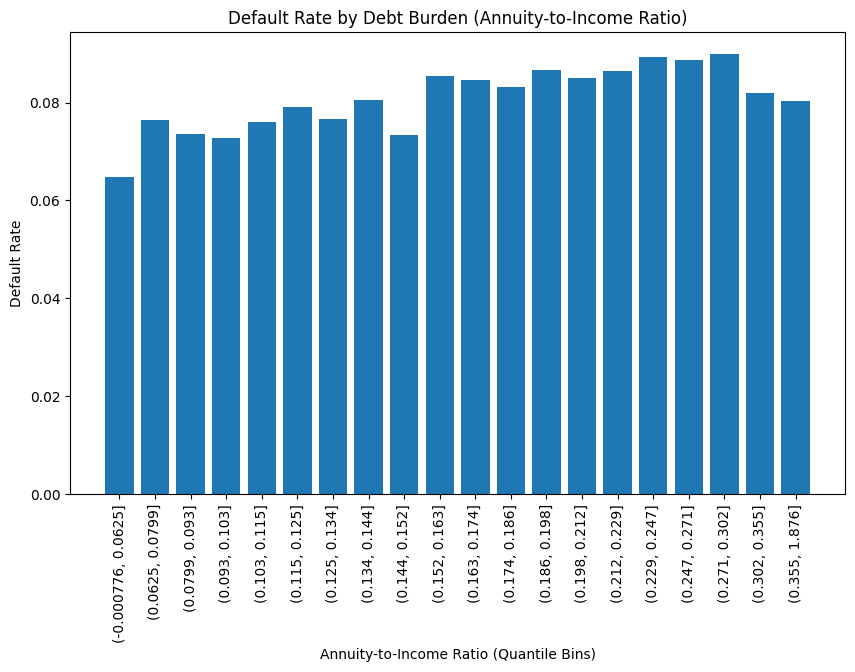

In [69]:
x = binned_annuity_target['ANNUITY_TO_INCOME'].astype(str)
y = binned_annuity_target[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Annuity-to-Income Ratio (Quantile Bins)')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by Debt Burden (Annuity-to-Income Ratio)')
plt.xticks(rotation=90)
plt.show()

In [70]:
train_df.head(1)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EMPLOYED_ANOMALY,YEARS_EMPLOYED,CREDIT_TO_INCOME,ANNUITY_TO_INCOME
273229,416712,0,Revolving loans,F,N,Y,1,112500.0,180000.0,9000.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0,17.553425,1.6,0.08


In [98]:
first_training_dataset = train_df[['YEARS_EMPLOYED','EMPLOYED_ANOMALY','ANNUITY_TO_INCOME','AMT_INCOME_TOTAL',target]]
first_training_dataset.head()

,YEARS_EMPLOYED,EMPLOYED_ANOMALY,ANNUITY_TO_INCOME,AMT_INCOME_TOTAL,TARGET
273229,17.553425,0,0.080000,112500.0,0
243443,1.835616,0,0.112489,202500.0,0
90102,7.758904,0,0.245250,90000.0,1
37979,4.865753,0,0.040816,220500.0,0
130754,1.380822,0,0.273333,94500.0,0


In [99]:
first_training_dataset.describe()

,YEARS_EMPLOYED,EMPLOYED_ANOMALY,ANNUITY_TO_INCOME,AMT_INCOME_TOTAL,TARGET
count,201792.000000,246008.000000,245999.000000,2.460080e+05,246008.000000
mean,6.526230,0.179734,0.180836,1.689096e+05,0.080729
std,6.400935,0.383967,0.094676,2.589069e+05,0.272419
min,-0.000000,0.000000,0.000224,2.565000e+04,0.000000
25%,2.104110,0.000000,0.114543,1.125000e+05,0.000000
50%,4.509589,0.000000,0.162618,1.467000e+05,0.000000
75%,8.693151,0.000000,0.228945,2.025000e+05,0.000000
max,49.073973,1.000000,1.875965,1.170000e+08,1.000000


In [100]:
first_training_dataset.isna().sum()

YEARS_EMPLOYED       44216
EMPLOYED_ANOMALY         0
ANNUITY_TO_INCOME        9
AMT_INCOME_TOTAL         0
TARGET                   0
dtype: int64

In [101]:
first_training_dataset[first_training_dataset['EMPLOYED_ANOMALY']==1]['EMPLOYED_ANOMALY'].sum()

np.int64(44216)

In [102]:
first_training_dataset = first_training_dataset.dropna(subset=['ANNUITY_TO_INCOME'])

In [105]:
first_training_dataset['YEARS_EMPLOYED'] = first_training_dataset['YEARS_EMPLOYED'].fillna(-1)

In [107]:
x = first_training_dataset.drop(target,axis=1)
y = first_training_dataset[target]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, stratify=y, random_state=23)

In [109]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(x_train,y_train)
gb.score(x_test,y_test)

0.9192682926829269

In [123]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

y_pred = gb.predict(x_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Specificity: {specificity}')

Precision: 0.0
Recall: 0.0
Specificity: 1.0


/home/nb/Projects/AppliedML/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [118]:
import numpy as np

print("Predicted positives:", np.sum(y_pred==1))
print("True positives in test:", np.sum(y_test==1))

Predicted positives: 0
True positives in test: 3972


In [119]:
y_proba = gb.predict_proba(x_test)[:,1]
print("Max proba:", y_proba.max())
print("Mean proba:", y_proba.mean())

Max proba: 0.439893893367164
Mean proba: 0.08084207445441126


In [121]:
fi = pd.Series(gb.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print(fi)

YEARS_EMPLOYED       0.567104
ANNUITY_TO_INCOME    0.181306
AMT_INCOME_TOTAL     0.149476
EMPLOYED_ANOMALY     0.102114
dtype: float64


In [124]:
print('ROC-AUC score:', roc_auc_score(y_test,y_proba))

ROC-AUC score: 0.6095047178885791


In [126]:
second_training_dataset = train_df[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',target]]
second_training_dataset.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,TARGET
273229,112500.0,180000.0,9000.0,0
243443,202500.0,432567.0,22779.0,0
90102,90000.0,203760.0,22072.5,1
37979,220500.0,180000.0,9000.0,0
130754,94500.0,239850.0,25830.0,0


In [127]:
second_training_dataset.isna().sum()

AMT_INCOME_TOTAL    0
AMT_CREDIT          0
AMT_ANNUITY         9
TARGET              0
dtype: int64

In [129]:
second_training_dataset = second_training_dataset.dropna(subset='AMT_ANNUITY')

In [130]:
second_training_dataset.isna().sum()

AMT_INCOME_TOTAL    0
AMT_CREDIT          0
AMT_ANNUITY         0
TARGET              0
dtype: int64

In [131]:
x = second_training_dataset.drop(target,axis=1)
y = second_training_dataset[target]

In [133]:
x_train,x_test,y_train,y_test = train_test_split(x,y,stratify=y,random_state=23)

In [134]:
gb = GradientBoostingClassifier()
gb.fit(x_train,y_train)
gb.score(x_test,y_test)

0.9192682926829269

In [141]:
y_proba = gb.predict_proba(x_test)[:,1]
print(f'ROC-AUC score: {roc_auc_score(y_test,y_proba)}')

ROC-AUC score: 0.59899611956019


In [137]:
fi = pd.Series(gb.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print(fi)

AMT_CREDIT          0.561209
AMT_ANNUITY         0.360259
AMT_INCOME_TOTAL    0.078532
dtype: float64


In [142]:
ext_cols = [col for col in train_df.columns if 'EXT_SOURCE' in col]
ext_cols

['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

In [144]:
train_df[ext_cols].describe()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,107419.000000,2.454660e+05,197222.000000
mean,0.501924,5.145526e-01,0.511020
std,0.211196,1.909737e-01,0.194636
min,0.014568,8.173617e-08,0.000527
25%,0.333327,3.926673e-01,0.370650
50%,0.505713,5.660017e-01,0.537070
75%,0.675050,6.637586e-01,0.667458
max,0.962693,8.549997e-01,0.893976


In [146]:
train_df.shape

(246008, 126)

In [145]:
train_df[ext_cols].isnull().mean()

EXT_SOURCE_1    0.563352
EXT_SOURCE_2    0.002203
EXT_SOURCE_3    0.198311
dtype: float64

In [147]:
train_df[ext_cols + [target]].corr()[target]

EXT_SOURCE_1   -0.155628
EXT_SOURCE_2   -0.160370
EXT_SOURCE_3   -0.180179
TARGET          1.000000
Name: TARGET, dtype: float64

When EXT_SOURCE_2 increases by 1 standard deviation, TARGET decreases by 0.16 standard deviations on average.

In [150]:
binned = train_df.groupby(pd.qcut(train_df['EXT_SOURCE_2'], 20, duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/608253393.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = train_df.groupby(pd.qcut(train_df['EXT_SOURCE_2'], 20, duplicates='drop'))[target].mean().reset_index()


In [151]:
binned

,EXT_SOURCE_2,TARGET
0,"(-0.0009999183, 0.133]",0.223236
1,"(0.133, 0.216]",0.144545
2,"(0.216, 0.279]",0.125041
3,"(0.279, 0.34]",0.115714
4,"(0.34, 0.393]",0.104701
5,"(0.393, 0.441]",0.094101
6,"(0.441, 0.479]",0.086124
7,"(0.479, 0.512]",0.080332
8,"(0.512, 0.541]",0.075538
9,"(0.541, 0.566]",0.073087


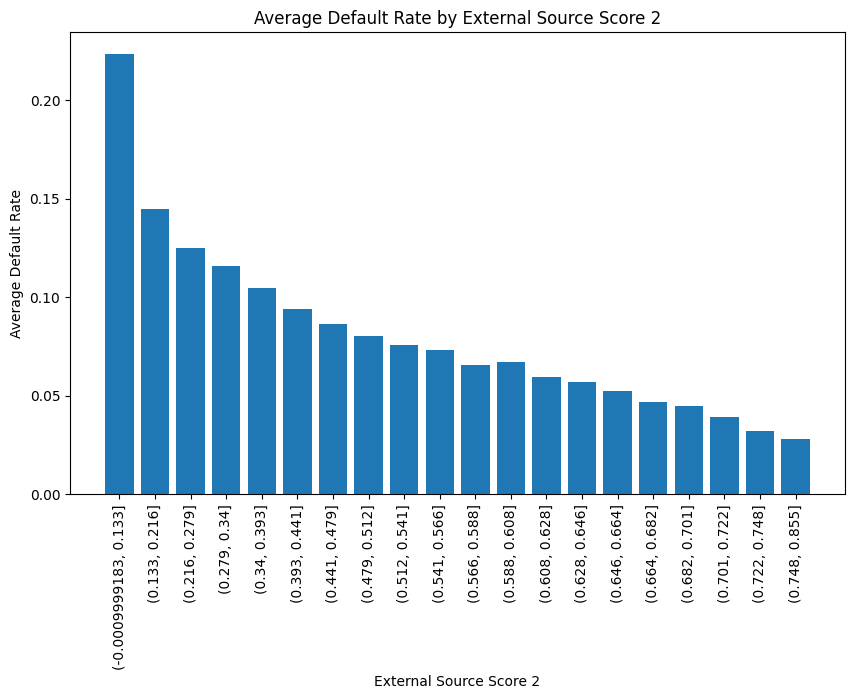

In [158]:
x = binned['EXT_SOURCE_2'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('External Source Score 2')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default Rate by External Source Score 2')
plt.xticks(rotation = 90)
plt.show()

In [161]:
train_df['EXT_SOURCE_MEAN'] = train_df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
train_df['EXT_SOURCE_MAX'] = train_df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].max(axis=1)
train_df['EXT_SOURCE_MIN'] = train_df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)

In [165]:
train_df[['EXT_SOURCE_MEAN',target]].corr()[target]

EXT_SOURCE_MEAN   -0.222811
TARGET             1.000000
Name: TARGET, dtype: float64

In [170]:
binned = train_df.groupby(pd.qcut(train_df['EXT_SOURCE_MEAN'],20,duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/628206406.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = train_df.groupby(pd.qcut(train_df['EXT_SOURCE_MEAN'],20,duplicates='drop'))[target].mean().reset_index()


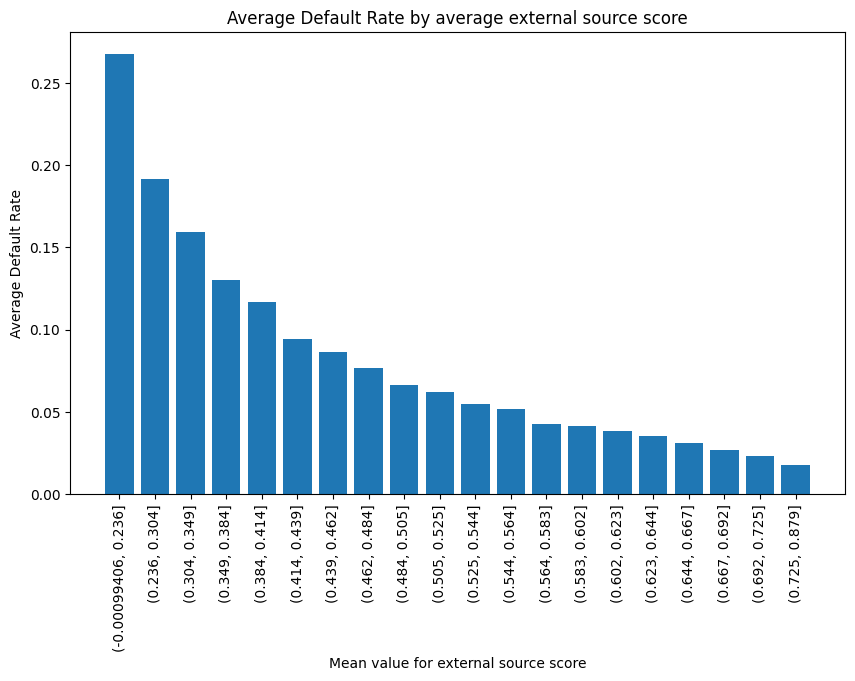

In [174]:
x = binned['EXT_SOURCE_MEAN'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Mean value for external source score')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default Rate by average external source score')
plt.xticks(rotation=90)
plt.show()

In [175]:
train_df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','EXT_SOURCE_MEAN','EXT_SOURCE_MAX','EXT_SOURCE_MIN',target]].corr()[target]

EXT_SOURCE_1      -0.155628
EXT_SOURCE_2      -0.160370
EXT_SOURCE_3      -0.180179
EXT_SOURCE_MEAN   -0.222811
EXT_SOURCE_MAX    -0.197111
EXT_SOURCE_MIN    -0.186636
TARGET             1.000000
Name: TARGET, dtype: float64

In [176]:
binned = train_df.groupby(pd.qcut(train_df['EXT_SOURCE_MAX'],20,duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/308531907.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = train_df.groupby(pd.qcut(train_df['EXT_SOURCE_MAX'],20,duplicates='drop'))[target].mean().reset_index()


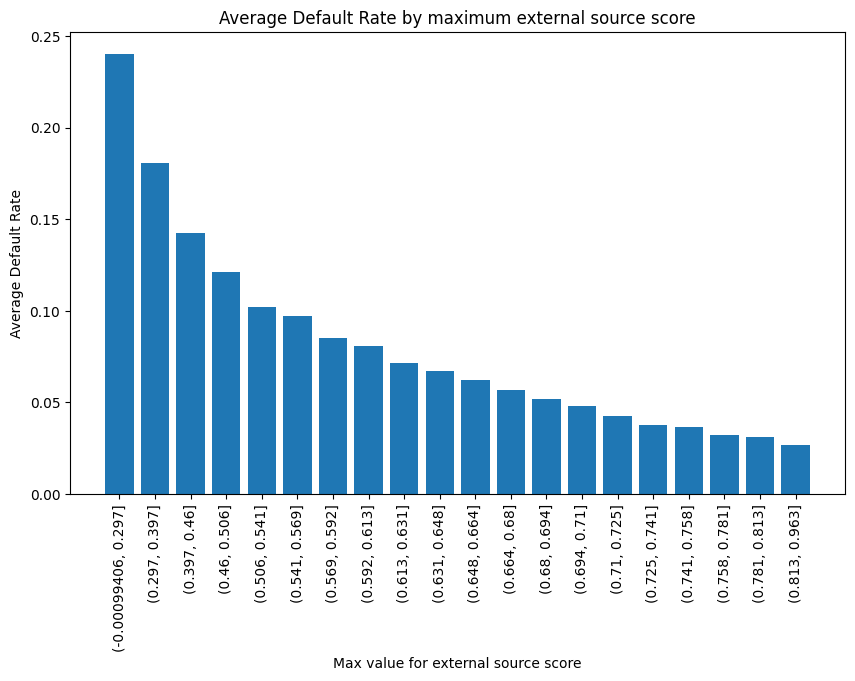

In [177]:
x = binned['EXT_SOURCE_MAX'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Max value for external source score')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default Rate by maximum external source score')
plt.xticks(rotation=90)
plt.show()

In [178]:
binned = train_df.groupby(pd.qcut(train_df['EXT_SOURCE_MIN'],20,duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/141611217.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = train_df.groupby(pd.qcut(train_df['EXT_SOURCE_MIN'],20,duplicates='drop'))[target].mean().reset_index()


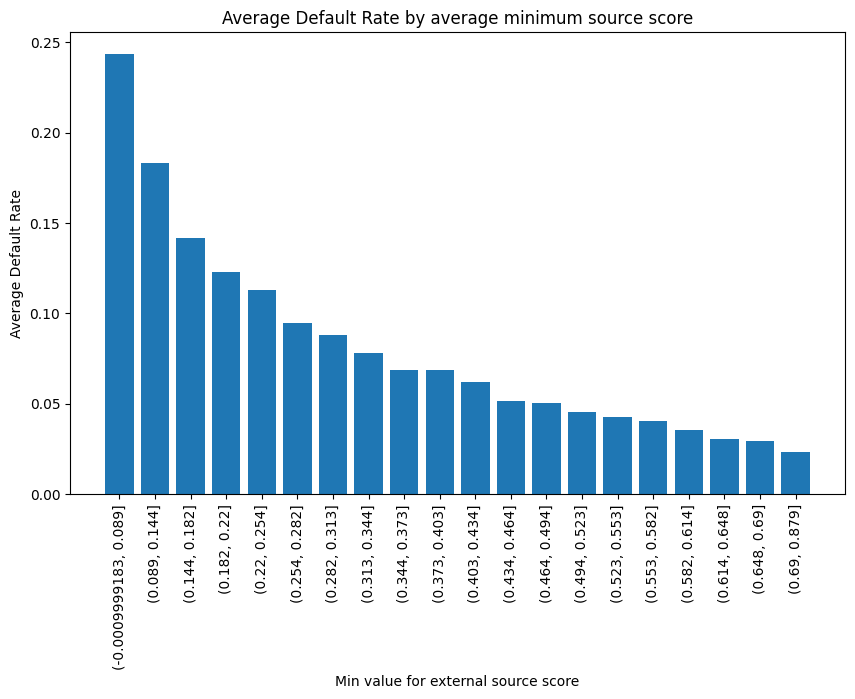

In [179]:
x = binned['EXT_SOURCE_MIN'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Min value for external source score')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default Rate by average minimum source score')
plt.xticks(rotation=90)
plt.show()

In [183]:
bureau_cols = [
'AMT_REQ_CREDIT_BUREAU_HOUR',
'AMT_REQ_CREDIT_BUREAU_DAY',
'AMT_REQ_CREDIT_BUREAU_WEEK',
'AMT_REQ_CREDIT_BUREAU_MON',
'AMT_REQ_CREDIT_BUREAU_QRT',
'AMT_REQ_CREDIT_BUREAU_YEAR'
]

train_df[bureau_cols + [target]].corr()[target].sort_values()

AMT_REQ_CREDIT_BUREAU_MON    -0.012750
AMT_REQ_CREDIT_BUREAU_QRT    -0.002279
AMT_REQ_CREDIT_BUREAU_HOUR    0.000921
AMT_REQ_CREDIT_BUREAU_WEEK    0.002073
AMT_REQ_CREDIT_BUREAU_DAY     0.003335
AMT_REQ_CREDIT_BUREAU_YEAR    0.019758
TARGET                        1.000000
Name: TARGET, dtype: float64

In [186]:
train_df[bureau_cols].describe()

,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,212758.000000,212758.000000,212758.000000,212758.000000,212758.000000,212758.000000
mean,0.006256,0.006834,0.034236,0.268540,0.265334,1.898998
std,0.082631,0.110036,0.204650,0.919519,0.834132,1.870292
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,4.000000,9.000000,8.000000,24.000000,261.000000,25.000000


In [184]:
binned = df.groupby(pd.qcut(train_df['AMT_REQ_CREDIT_BUREAU_YEAR'], 20, duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/2451152560.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df.groupby(pd.qcut(train_df['AMT_REQ_CREDIT_BUREAU_YEAR'], 20, duplicates='drop'))[target].mean().reset_index()


In [185]:
binned

,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
0,"(-0.001, 1.0]",0.072330
1,"(1.0, 2.0]",0.080827
2,"(2.0, 3.0]",0.079773
3,"(3.0, 4.0]",0.082644
4,"(4.0, 6.0]",0.084650
5,"(6.0, 25.0]",0.093967


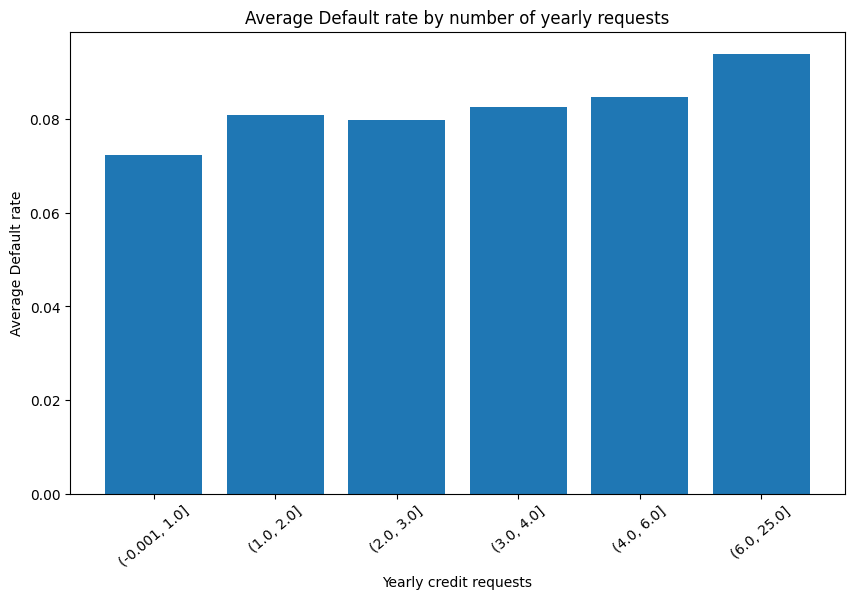

In [189]:
x = binned['AMT_REQ_CREDIT_BUREAU_YEAR'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Yearly credit requests')
ax.set_ylabel('Average Default rate')
ax.set_title('Average Default rate by number of yearly requests')
plt.xticks(rotation = 40)
plt.show()

In [192]:
train_df.groupby(train_df['AMT_REQ_CREDIT_BUREAU_MON']>0)[target].mean()

AMT_REQ_CREDIT_BUREAU_MON
False    0.081979
True     0.073228
Name: TARGET, dtype: float64

Correlation magnitude depends on:
1. Distribution
2. Sparsity
3. Measurment window
4. Noise level

In [198]:
train_df[train_df['AMT_REQ_CREDIT_BUREAU_MON']>0]['AMT_REQ_CREDIT_BUREAU_MON'].value_counts()

np.int64(35137)

In [201]:
(train_df[bureau_cols]>0).mean()

AMT_REQ_CREDIT_BUREAU_HOUR    0.005179
AMT_REQ_CREDIT_BUREAU_DAY     0.004727
AMT_REQ_CREDIT_BUREAU_WEEK    0.027654
AMT_REQ_CREDIT_BUREAU_MON     0.142829
AMT_REQ_CREDIT_BUREAU_QRT     0.163865
AMT_REQ_CREDIT_BUREAU_YEAR    0.631134
dtype: float64

All the features are sparce except for 'AMT_REQ_CREDIT_BUREAU_YEAR'

In [202]:
train_df['AGE_YEARS'] = -train_df['DAYS_BIRTH']/365

In [205]:
binned = train_df.groupby(pd.qcut(train_df['AGE_YEARS'], 20, duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/2437382775.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = train_df.groupby(pd.qcut(train_df['AGE_YEARS'], 20, duplicates='drop'))[target].mean().reset_index()


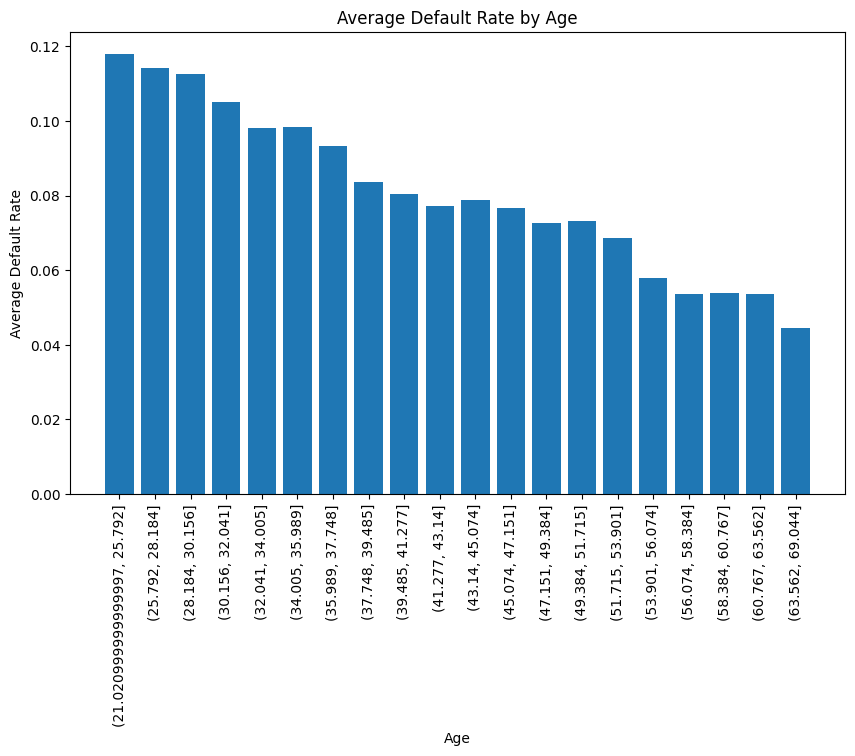

In [207]:
x = binned['AGE_YEARS'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Age')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default Rate by Age')
plt.xticks(rotation=90)
plt.show()

In [213]:
train_df[['AGE_YEARS']+[target]].corr()[target]

AGE_YEARS   -0.077968
TARGET       1.000000
Name: TARGET, dtype: float64

In [214]:
train_df['CNT_CHILDREN'].describe()

count    246008.000000
mean          0.417173
std           0.722396
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

In [215]:
binned = train_df.groupby(pd.qcut(train_df['CNT_CHILDREN'], 20, duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/3629010111.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = train_df.groupby(pd.qcut(train_df['CNT_CHILDREN'], 20, duplicates='drop'))[target].mean().reset_index()


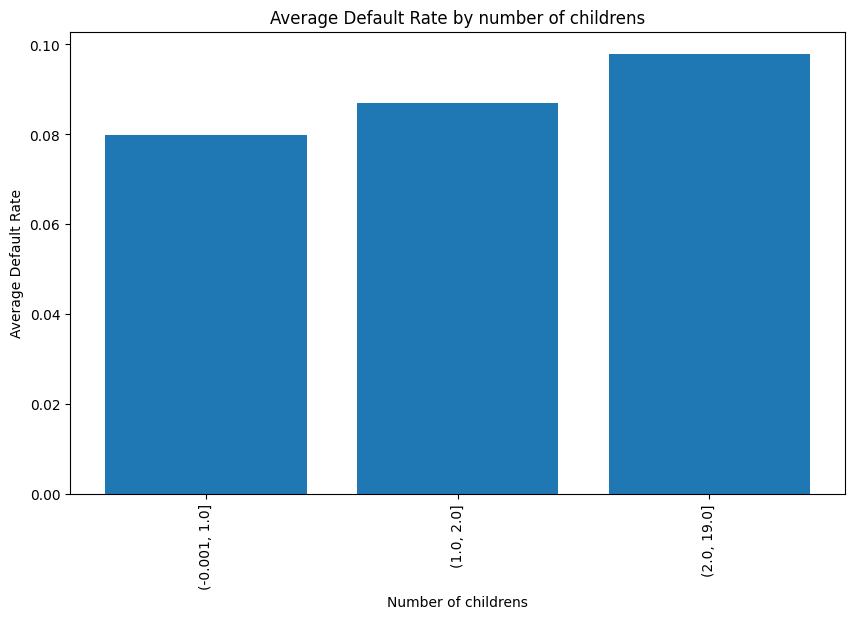

In [216]:
x = binned['CNT_CHILDREN'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Number of childrens')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default Rate by number of childrens')
plt.xticks(rotation=90)
plt.show()

In [217]:
train_df[['CNT_CHILDREN',target]].corr()[target]

CNT_CHILDREN    0.019043
TARGET          1.000000
Name: TARGET, dtype: float64

In [219]:
binned = train_df.groupby(pd.qcut(train_df['CNT_FAM_MEMBERS'], 20, duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/3214495257.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = train_df.groupby(pd.qcut(train_df['CNT_FAM_MEMBERS'], 20, duplicates='drop'))[target].mean().reset_index()


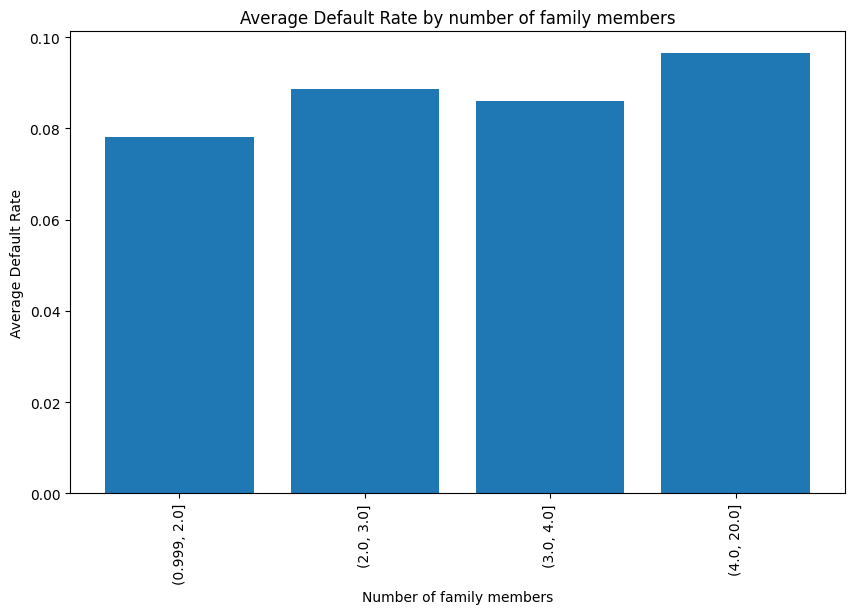

In [220]:
x = binned['CNT_FAM_MEMBERS'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Number of family members')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default Rate by number of family members')
plt.xticks(rotation=90)
plt.show()

In [221]:
train_df[['CNT_FAM_MEMBERS',target]].corr()[target]

CNT_FAM_MEMBERS    0.009611
TARGET             1.000000
Name: TARGET, dtype: float64

In [222]:
df_test = train_df.copy()

In [224]:
df_test['FAMILY'] = df_test['CNT_CHILDREN'] + df_test['CNT_FAM_MEMBERS']

In [226]:
binned = df_test.groupby(pd.qcut(df_test['FAMILY'], 20, duplicates='drop'))[target].mean().reset_index()

/tmp/ipykernel_312844/3844186353.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df_test.groupby(pd.qcut(df_test['FAMILY'], 20, duplicates='drop'))[target].mean().reset_index()


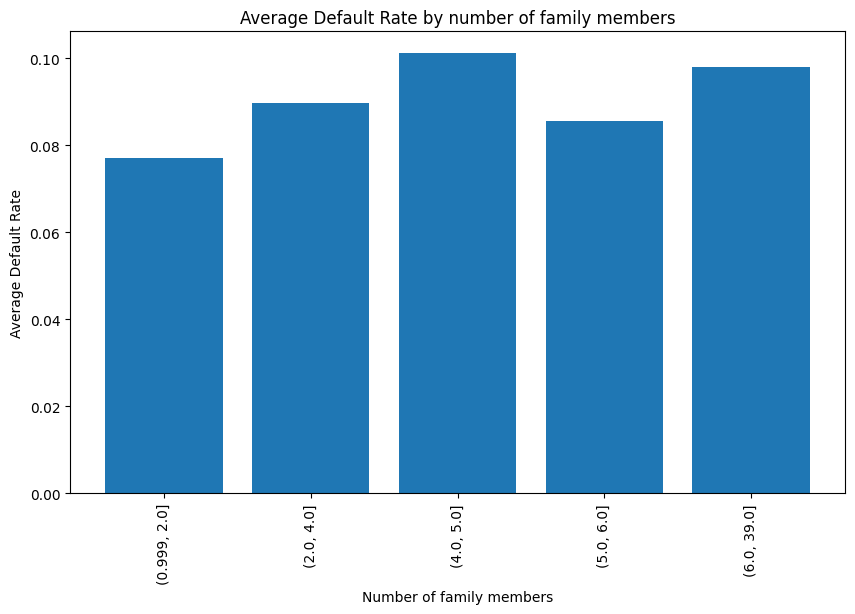

In [227]:
x = binned['FAMILY'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Number of family members')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default Rate by number of family members')
plt.xticks(rotation=90)
plt.show()

In [228]:
df_test[['FAMILY',target]].corr()[target]

FAMILY    0.014212
TARGET    1.000000
Name: TARGET, dtype: float64

In [230]:
train_df['NAME_HOUSING_TYPE'].value_counts(normalize=True)

NAME_HOUSING_TYPE
House / apartment      0.887378
With parents           0.048189
Municipal apartment    0.036487
Rented apartment       0.015817
Office apartment       0.008439
Co-op apartment        0.003691
Name: proportion, dtype: float64

In [236]:
housing_default = train_df.groupby(train_df['NAME_HOUSING_TYPE'])[target].mean().sort_values().reset_index()
housing_default

,NAME_HOUSING_TYPE,TARGET
0,Office apartment,0.065992
1,House / apartment,0.077965
2,Municipal apartment,0.084447
3,Co-op apartment,0.084802
4,With parents,0.115985
5,Rented apartment,0.126703


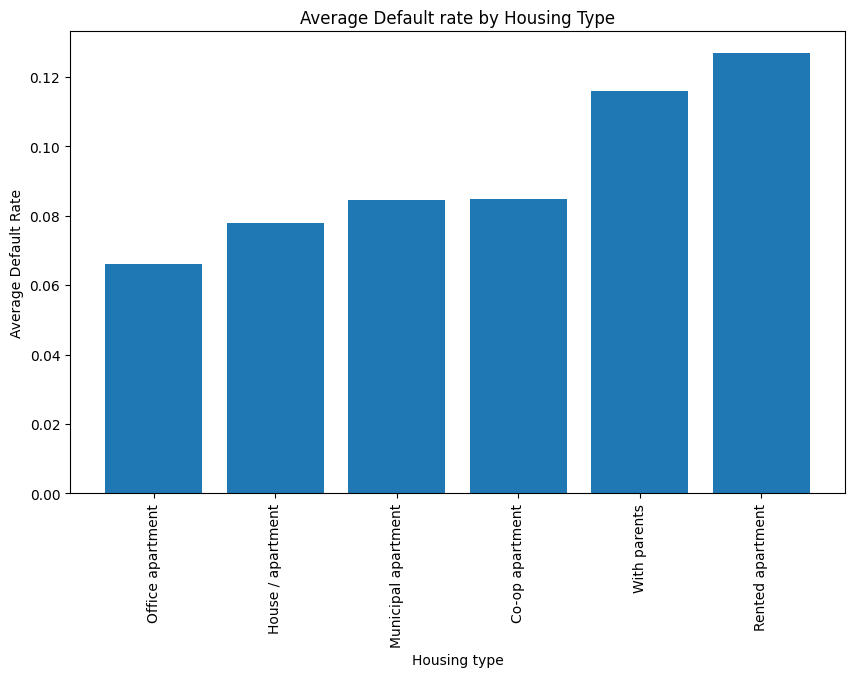

In [237]:
x = housing_default['NAME_HOUSING_TYPE']
y = housing_default[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Housing type')
ax.set_ylabel('Average Default Rate')
ax.set_title('Average Default rate by Housing Type')
plt.xticks(rotation=90)
plt.show()

In [242]:
housing_summary = train_df.groupby(train_df['NAME_HOUSING_TYPE'])[target].agg(['mean','count']).sort_values('mean')
housing_summary

,mean,count
NAME_HOUSING_TYPE,,
Office apartment,0.065992,2076
House / apartment,0.077965,218302
Municipal apartment,0.084447,8976
Co-op apartment,0.084802,908
With parents,0.115985,11855
Rented apartment,0.126703,3891


In [243]:
train_df.groupby(['NAME_HOUSING_TYPE'])['AGE_YEARS'].mean().sort_values()

NAME_HOUSING_TYPE
With parents           32.027898
Rented apartment       35.893637
Co-op apartment        38.995519
Office apartment       41.929015
House / apartment      44.694321
Municipal apartment    45.413915
Name: AGE_YEARS, dtype: float64

In [244]:
train_df.groupby(['NAME_HOUSING_TYPE'])['ANNUITY_TO_INCOME'].mean().sort_values()

NAME_HOUSING_TYPE
Rented apartment       0.169524
With parents           0.172374
Office apartment       0.174960
Co-op apartment        0.176743
Municipal apartment    0.181101
House / apartment      0.181560
Name: ANNUITY_TO_INCOME, dtype: float64

In [245]:
train_df.groupby(['NAME_HOUSING_TYPE'])['YEARS_EMPLOYED'].mean().sort_values()

NAME_HOUSING_TYPE
With parents           4.211100
Rented apartment       4.311739
Co-op apartment        5.749963
House / apartment      6.701610
Municipal apartment    7.053012
Office apartment       7.155351
Name: YEARS_EMPLOYED, dtype: float64

In [246]:
train_df.groupby(['NAME_HOUSING_TYPE'])['EXT_SOURCE_MEAN'].mean().sort_values()

NAME_HOUSING_TYPE
With parents           0.442217
Rented apartment       0.454054
Co-op apartment        0.497851
Office apartment       0.500643
House / apartment      0.513628
Municipal apartment    0.519201
Name: EXT_SOURCE_MEAN, dtype: float64

In [248]:
train_df.groupby(['FLAG_OWN_REALTY'])[target].agg(['mean', 'count'])

,mean,count
FLAG_OWN_REALTY,,
N,0.083096,75286
Y,0.079685,170722


In [260]:
train_df['NAME_HOUSING_TYPE'] = train_df['NAME_HOUSING_TYPE'].replace({'Co-op apartment':'Other'})

In [259]:
train_df['REGION_POPULATION_RELATIVE'].isna().mean()

np.float64(0.0)

In [254]:
binned = train_df.groupby(pd.qcut(train_df['REGION_POPULATION_RELATIVE'], 20, duplicates='drop'))[target].mean().reset_index()
train_df[['REGION_POPULATION_RELATIVE', target]].corr()[target]

/tmp/ipykernel_312844/995914462.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = train_df.groupby(pd.qcut(train_df['REGION_POPULATION_RELATIVE'], 20, duplicates='drop'))[target].mean().reset_index()


REGION_POPULATION_RELATIVE   -0.036988
TARGET                        1.000000
Name: TARGET, dtype: float64

[]

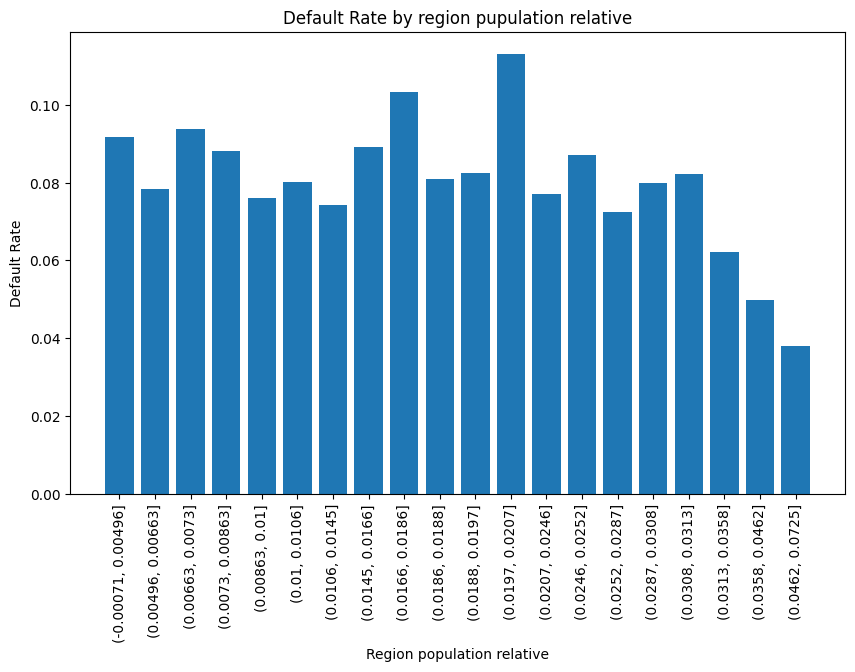

In [258]:
x = binned['REGION_POPULATION_RELATIVE'].astype(str)
y = binned[target]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Region population relative')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by region pupulation relative')
plt.xticks(rotation=90)
plt.plot()

In [262]:
train_df.groupby(train_df['FLAG_OWN_CAR'])[target].agg(['mean','count'])

,mean,count
FLAG_OWN_CAR,,
N,0.085054,162367
Y,0.072333,83641


In [263]:
train_df['FLAG_OWN_CAR'].isna().sum()

np.int64(0)

In [264]:
train_df['NAME_INCOME_TYPE'].value_counts(normalize=True)

NAME_INCOME_TYPE
Working                 0.516841
Commercial associate    0.232712
Pensioner               0.179689
State servant           0.070567
Unemployed              0.000073
Student                 0.000065
Businessman             0.000037
Maternity leave         0.000016
Name: proportion, dtype: float64

In [265]:
train_df['NAME_INCOME_TYPE'].isna().sum()

np.int64(0)

In [272]:
income_type_summary = train_df.groupby(['NAME_INCOME_TYPE'])[target].agg(['mean','count']).sort_values('mean').reset_index()
income_type_summary

,NAME_INCOME_TYPE,mean,count
0,Businessman,0.000000,9
1,Student,0.000000,16
2,Pensioner,0.053455,44205
3,State servant,0.057604,17360
4,Commercial associate,0.074971,57249
5,Working,0.095936,127147
6,Maternity leave,0.250000,4
7,Unemployed,0.333333,18


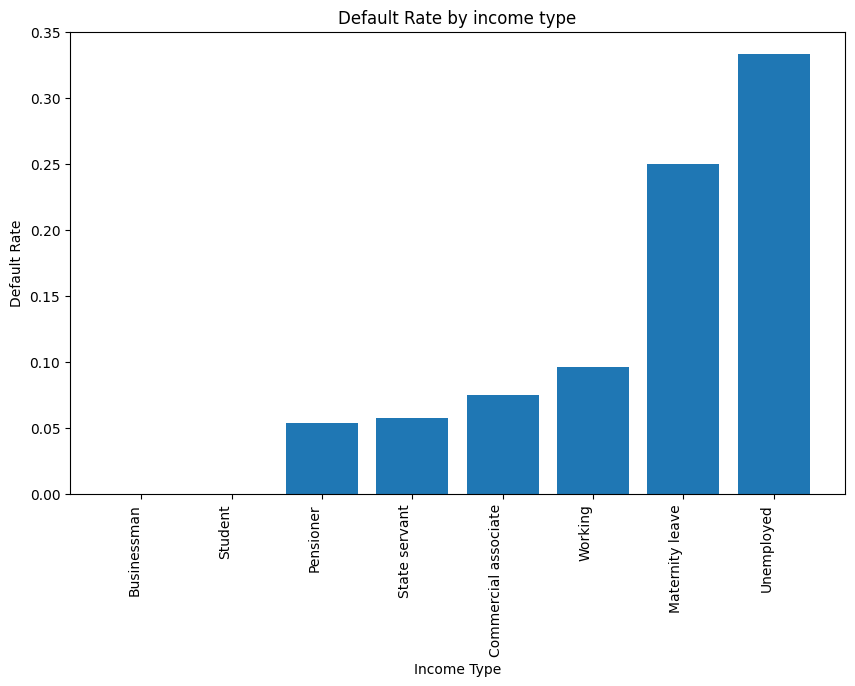

In [273]:
x = income_type_summary['NAME_INCOME_TYPE']
y = income_type_summary['mean']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Income Type')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by income type')
plt.xticks(rotation=90, ha='right')
plt.show()

In [274]:
train_df['NAME_INCOME_TYPE_CLEAN'] = train_df['NAME_INCOME_TYPE'].replace({'Businessman':'Other','Student':'Other','Maternity leave':'Other','Unemployed':'Other'})

In [276]:
income_type_summary = train_df.groupby(['NAME_INCOME_TYPE_CLEAN'])[target].agg(['mean','count']).sort_values('mean').reset_index()
income_type_summary

,NAME_INCOME_TYPE_CLEAN,mean,count
0,Pensioner,0.053455,44205
1,State servant,0.057604,17360
2,Commercial associate,0.074971,57249
3,Working,0.095936,127147
4,Other,0.148936,47


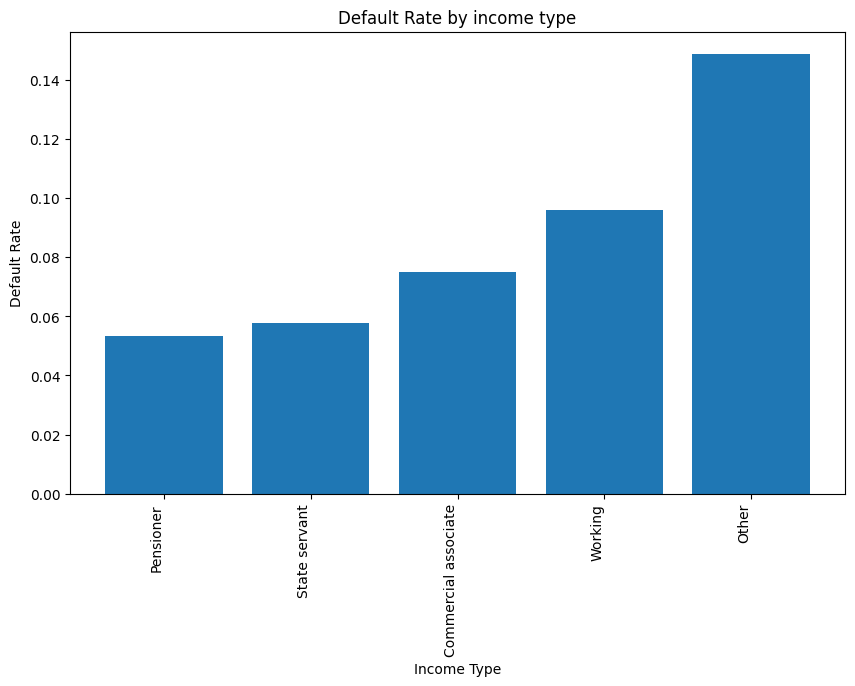

In [277]:
x = income_type_summary['NAME_INCOME_TYPE_CLEAN']
y = income_type_summary['mean']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Income Type')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by income type')
plt.xticks(rotation=90, ha='right')
plt.show()

In [291]:
train_df['OCCUPATION_TYPE'].isna().mean()

np.float64(0.31347354557575363)

In [290]:
train_df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 44312
Sales staff              25609
Core staff               22003
Managers                 17047
Drivers                  14819
High skill tech staff     9084
Accountants               7866
Medicine staff            6834
Security staff            5340
Cooking staff             4782
Cleaning staff            3753
Private service staff     2129
Low-skill Laborers        1698
Waiters/barmen staff      1080
Secretaries               1057
Realty agents              586
HR staff                   461
IT staff                   431
Name: count, dtype: int64

In [279]:
occ_summary = (train_df.assign(OCC=train_df['OCCUPATION_TYPE'].fillna('Missing')).groupby('OCC')[target].agg(['mean','count']).sort_values('count',ascending=False))
occ_summary

,mean,count
OCC,,
Missing,0.065161,77117
Laborers,0.106833,44312
Sales staff,0.095318,25609
Core staff,0.062128,22003
Managers,0.062181,17047
Drivers,0.113705,14819
High skill tech staff,0.060766,9084
Accountants,0.048436,7866
Medicine staff,0.067457,6834


In [286]:
occ_summary = occ_summary.reset_index().sort_values('mean')

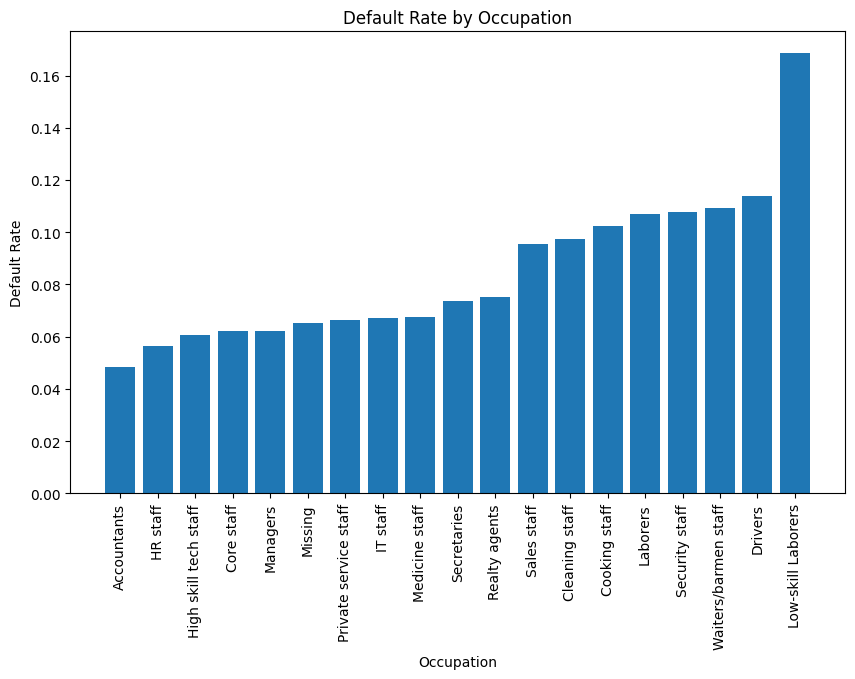

In [288]:
x = occ_summary['OCC']
y = occ_summary['mean']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Occupation')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by Occupation')
plt.xticks(rotation=90)
plt.show()

In [297]:
occ = train_df['OCCUPATION_TYPE'].fillna('Missing')

occ_stats = train_df.assign(OCC=occ).groupby('OCC')[target].agg(['mean','count'])
baseline = train_df[target].mean()
#rule:
keep = occ_stats.index[(occ_stats['count']>=2000)]
keep = keep.union(occ_stats.index[(occ_stats['count'] >= 1000) & (occ_stats['mean'] >= baseline + 0.03)])
train_df['OCCUPATION_CLEAN'] = occ.where(occ.isin(keep), 'Other')
train_df['OCCUPATION_CLEAN'].value_counts()

OCCUPATION_CLEAN
Missing                  77117
Laborers                 44312
Sales staff              25609
Core staff               22003
Managers                 17047
Drivers                  14819
High skill tech staff     9084
Accountants               7866
Medicine staff            6834
Security staff            5340
Cooking staff             4782
Cleaning staff            3753
Other                     3615
Private service staff     2129
Low-skill Laborers        1698
Name: count, dtype: int64

In [295]:
baseline

np.float64(0.08072908198107379)

In [299]:
train_df['ORGANIZATION_TYPE'].nunique()

58

In [308]:
train_df['ORGANIZATION_TYPE'].value_counts().head(15)

ORGANIZATION_TYPE
Business Entity Type 3    54489
XNA                       44216
Self-employed             30697
Other                     13344
Medicine                   8976
Business Entity Type 2     8402
Government                 8298
School                     7092
Trade: type 7              6212
Kindergarten               5452
Construction               5333
Business Entity Type 1     4839
Transport: type 4          4341
Trade: type 3              2782
Industry: type 9           2704
Name: count, dtype: int64

In [302]:
train_df['ORGANIZATION_TYPE'].isna().sum()

np.int64(0)

In [309]:
org_summary = (train_df.groupby(['ORGANIZATION_TYPE'])[target].agg(['mean','count']).sort_values('count',ascending=False))
org_summary.head(15)

,mean,count
ORGANIZATION_TYPE,,
Business Entity Type 3,0.093450,54489
XNA,0.053578,44216
Self-employed,0.102323,30697
Other,0.075839,13344
Medicine,0.067513,8976
Business Entity Type 2,0.085099,8402
Government,0.070137,8298
School,0.059081,7092
Trade: type 7,0.094012,6212


In [312]:
org_summary.head(10)['count'].sum() / len(train_df) * 100

np.float64(76.08614354004747)

In [314]:
baseline = train_df[target].mean()
baseline

np.float64(0.08072908198107379)

In [315]:
org = train_df['ORGANIZATION_TYPE'].fillna('Missing')

In [339]:
org_stats = train_df.assign(ORG=org).groupby('ORG')[target].agg(['mean','count'])
org_stats = org_stats.sort_values('count', ascending=False)
keep = org_stats.index[org_stats['count'] >= 2000]
keep = keep.union(org_stats.index[(org_stats['count'] >= 1000) & ((org_stats['mean'] >= baseline + 0.03) | (org_stats['mean'] <= baseline - 0.02))])
train_df['ORG_CLEAN'] = org.where(org.isin(keep), 'Other_Org')
train_df.groupby('ORG_CLEAN')[target].agg(['mean','count']).sort_values('count',ascending=False).head(25)

,mean,count
ORG_CLEAN,,
Business Entity Type 3,0.093450,54489
XNA,0.053578,44216
Self-employed,0.102323,30697
Other_Org,0.082235,18970
Other,0.075839,13344
Medicine,0.067513,8976
Business Entity Type 2,0.085099,8402
Government,0.070137,8298
School,0.059081,7092


In [340]:
train_df['ORG_CLEAN'].nunique()

26

In [348]:
train_df['ORG_CLEAN'].value_counts().head(10).sum() / len(train_df) * 100

np.float64(81.58108679392541)

In [349]:
train_df['ORG_CLEAN'].value_counts().head(15)

ORG_CLEAN
Business Entity Type 3    54489
XNA                       44216
Self-employed             30697
Other_Org                 18970
Other                     13344
Medicine                   8976
Business Entity Type 2     8402
Government                 8298
School                     7092
Trade: type 7              6212
Kindergarten               5452
Construction               5333
Business Entity Type 1     4839
Transport: type 4          4341
Trade: type 3              2782
Name: count, dtype: int64

Available features

Numeric:
1. AGE_YEARS
2. YEARS_EMPLOYED + EMPLOYED_ANOMALY
3. AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY
4. CREDIT_TO_INCOME, ANNUITY_TO_INCOME

External scores:
1. EXT_SOURCE_1/2/3, EXT_SOURCE_MEAN (best of the aggregates)

Count features
1. AMT_REQ_CREDIT_BUREAU_YEAR (the others are sparse/noise)

Categorical cleaned
1. NAME_INCOME_TYPE_CLEAN
2. OCCUPATION_CLEAN
3. ORG_CLEAN
4. NAME_HOUSING_TYPE

In [358]:
features = [
    'AGE_YEARS',
    'YEARS_EMPLOYED',
    'EMPLOYED_ANOMALY',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'CREDIT_TO_INCOME',
    'ANNUITY_TO_INCOME',
    'EXT_SOURCE_MEAN',
    'AMT_REQ_CREDIT_BUREAU_YEAR',
    'NAME_INCOME_TYPE_CLEAN',
    'OCCUPATION_CLEAN',
    'ORG_CLEAN',
    'NAME_HOUSING_TYPE',
]

df_model = train_df[features + [target]].copy()

In [360]:
X = df_model.drop(columns=[target])
Y = df_model[target]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=23)

In [361]:
df_model.isna().mean().sort_values(ascending=False).head(15)

YEARS_EMPLOYED                0.179734
AMT_REQ_CREDIT_BUREAU_YEAR    0.135158
EXT_SOURCE_MEAN               0.000557
AMT_ANNUITY                   0.000037
ANNUITY_TO_INCOME             0.000037
EMPLOYED_ANOMALY              0.000000
AGE_YEARS                     0.000000
CREDIT_TO_INCOME              0.000000
AMT_CREDIT                    0.000000
AMT_INCOME_TOTAL              0.000000
NAME_INCOME_TYPE_CLEAN        0.000000
OCCUPATION_CLEAN              0.000000
ORG_CLEAN                     0.000000
NAME_HOUSING_TYPE             0.000000
TARGET                        0.000000
dtype: float64

Numeric: YEARS_EMPLOYED, AMT_REQ_CREDIT_BUREAU_YEAR , EXT_SOURCE_MEAN, AMT_ANNUITY, ANNUITY_TO_INCOME, AGE_YEARS, CREDIT_TO_INCOME, AMT_CREDIT, AMT_INCOME_TOTAL

Categorical: EMPLOYED_ANOMALY, NAME_INCOME_TYPE_CLEAN, OCCUPATION_CLEAN, ORG_CLEAN, NAME_HOUSING_TYPE

In [362]:
num_cols = [
    'YEARS_EMPLOYED',
    'AMT_REQ_CREDIT_BUREAU_YEAR',
    'EXT_SOURCE_MEAN',
    'AMT_ANNUITY',
    'ANNUITY_TO_INCOME',
    'AGE_YEARS',
    'CREDIT_TO_INCOME',
    'AMT_CREDIT',
    'AMT_INCOME_TOTAL',
    'EMPLOYED_ANOMALY',   # treat as numeric/binary
]
cat_cols = [
    'NAME_INCOME_TYPE_CLEAN',
    'OCCUPATION_CLEAN',
    'ORG_CLEAN',
    'NAME_HOUSING_TYPE',
]

In [365]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [367]:
numeric_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_lr = ColumnTransformer(
    transformers=[
        ('num', numeric_lr, num_cols),
        ('cat', categorical, cat_cols),
    ],
    remainder='drop'
)

In [369]:
numeric_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', numeric_tree, num_cols),
        ('cat', categorical, cat_cols),
    ],
    remainder='drop'
)

In [371]:
from sklearn.linear_model import LogisticRegression

In [372]:
clf_lr = Pipeline(steps=[
    ('preprocess', preprocess_lr),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
clf_lr.fit(x_train, y_train)
proba_lr = clf_lr.predict_proba(x_test)[:,1]
print('LR ROC-AUC:', roc_auc_score(y_test,proba_lr))

LR ROC-AUC: 0.7346341146816127


In [373]:
clf_gb = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('model', GradientBoostingClassifier(random_state=23)),
])
clf_gb.fit(x_train,y_train)
proba_gb = clf_gb.predict_proba(x_test)[:,1]
print('GB ROC-AUC:', roc_auc_score(y_test,proba_gb))

GB ROC-AUC: 0.7384543896597429


In [374]:
print('Base rate in test:', y_test.mean())
print('Mean predicted proba LR:', proba_lr.mean())
print('Max predicted proba LR:', proba_lr.max())
print('Mean predicted proba GB:', proba_gb.mean())
print('Max predicted proba GB:', proba_gb.max())

Base rate in test: 0.0807284256737531
Mean predicted proba LR: 0.4342460953402595
Max predicted proba LR: 0.9525510996125693
Mean predicted proba GB: 0.08075440554576704
Max predicted proba GB: 0.7519726323323989


In [375]:
clf_lr_unweighted = Pipeline(steps=[
    ('preprocess', preprocess_lr),
    ('model', LogisticRegression(max_iter=2000)),
])

clf_lr_unweighted.fit(x_train,y_train)
proba_lr_unweighted = clf_lr_unweighted.predict_proba(x_test)[:,1]
print('LR (Unweighted) ROC-AUC', roc_auc_score(y_test,proba_lr_unweighted))
print('Mean predicted proba LR Unweighted', proba_lr_unweighted.mean())
print('Max predicted proba LR Unweighted', proba_lr_unweighted.max())

LR (Unweighted) ROC-AUC 0.7345241920059922
Mean predicted proba LR Unweighted 0.08077764091598974
Max predicted proba LR Unweighted 0.6188158512685871


In [376]:
r = 0.20
LGD = 0.60
threshold_profit = r/(r+LGD)
threshold_profit

0.25

r - 20% annual effective rate
LGD - 60% loss of principal on default

In [379]:
thr = threshold_profit
L = x_test['AMT_CREDIT'].values
p = proba_lr_unweighted

approve = (p < thr).astype(int)
print('Profit threshold:', thr)
print('Approval rate:', approve.mean())

approved_idx = approve == 1
print('Default rate among approved:', y_test.values[approved_idx].mean())
expected_profit = approve * ((1-p) * (L * r) - p * (L * LGD))
print('Total expected profit:', expected_profit.sum())
print('Avg expected profit per approved loan:', expected_profit[approved_idx].mean())

Profit threshold: 0.25
Approval rate: 0.9652859639852038
Default rate among approved: 0.07278814165999915
Total expected profit: 4187243260.201067
Avg expected profit per approved loan: 88163.62614648307


In [385]:
y_true = y_test.values
realized_profit = approve * ((1-y_true) * (L*r) - y_true * (L * LGD))

print('Total realized profit:', realized_profit.sum())
print('Avg realized profit per approved loan:', realized_profit[approved_idx].mean())

Total realized profit: 4196277161.1
Avg realized profit per approved loan: 88353.83756053395


In [389]:
realized_profit_without_model = ((1-y_true) * (L*r) - y_true * (L*LGD))
print('Total realized profit without model:', realized_profit_without_model.sum())
print('Difference in profit:', realized_profit.sum()-realized_profit_without_model.sum())

Total realized profit without model: 4160858020.2000003
Difference in profit: 35419140.89999962


In [400]:
r = 0.2
LGD = 0.6
L = x_test['AMT_CREDIT'].values
p = proba_lr_unweighted
y_true = y_test.values

thresholds = np.linspace(0.01, 0.5, 50)
rows = []
for t in thresholds:
    approve = (p < t)
    approval_rate = approve.mean()
    default_rate = y_true[approve].mean() if approve.any() else np.nan

    realized_profit = ((1-y_true) * (L*r) - y_true * (L * LGD))
    realized_profit_policy = realized_profit[approve].sum()

    rows.append((t, approval_rate, default_rate, realized_profit_policy))
profit_table = pd.DataFrame(rows, columns=['thr', 'approval_rate', 'default_rate_approved', 'realized_profit'])
profit_table.sort_values('realized_profit', ascending=False).head(10)

,thr,approval_rate,default_rate_approved,realized_profit
21,0.22,0.948722,0.069667,4.197461e+09
23,0.24,0.960571,0.071876,4.197376e+09
24,0.25,0.965286,0.072788,4.196277e+09
22,0.23,0.955124,0.070903,4.195864e+09
30,0.31,0.983314,0.076063,4.195519e+09
28,0.29,0.978253,0.075064,4.194906e+09
31,0.32,0.985305,0.076528,4.194033e+09
20,0.21,0.941832,0.068472,4.193748e+09
25,0.26,0.969046,0.073638,4.193587e+09
27,0.28,0.975590,0.074644,4.193313e+09


In [401]:
profit_table['default_rate_approved'].mean()

np.float64(0.06381516144558642)

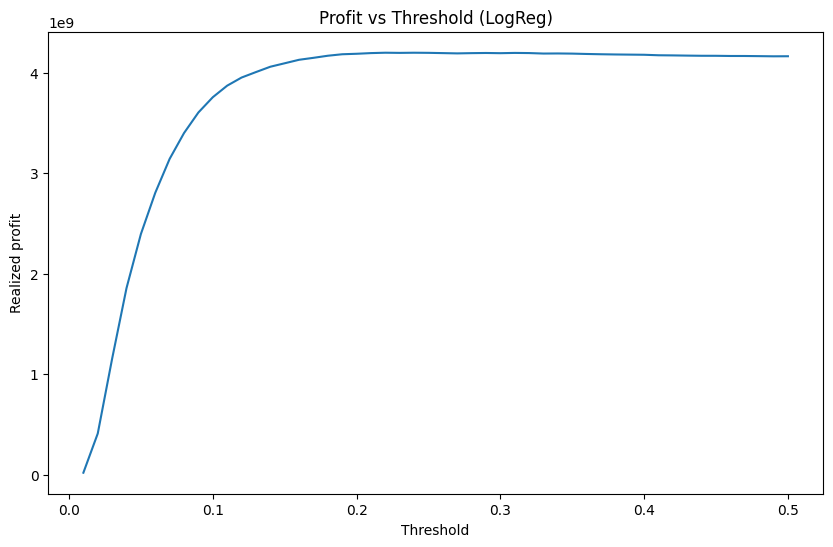

In [403]:
x = profit_table['thr']
y = profit_table['realized_profit']

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x, y)
ax.set_xlabel('Threshold')
ax.set_ylabel('Realized profit')
ax.set_title('Profit vs Threshold (LogReg)')
plt.show()

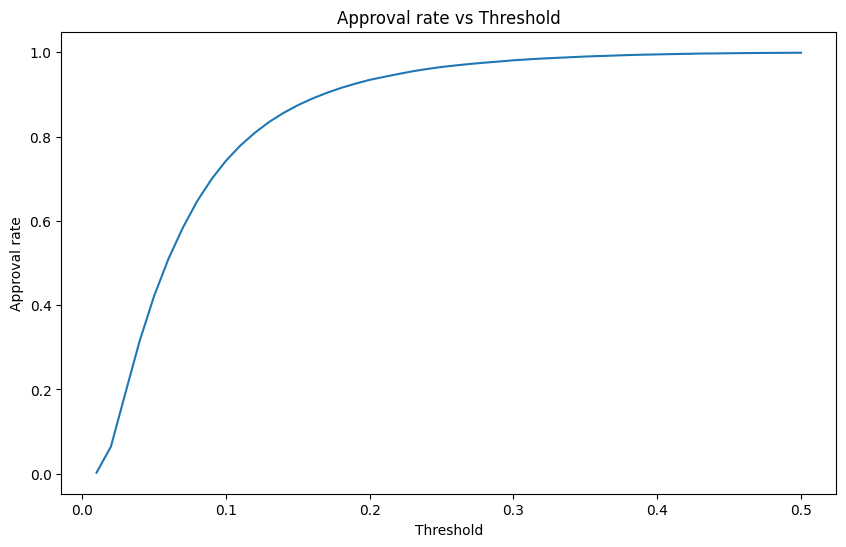

In [404]:
x = profit_table['thr']
y = profit_table['approval_rate']

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x,y)
ax.set_xlabel('Threshold')
ax.set_ylabel('Approval rate')
ax.set_title('Approval rate vs Threshold')
plt.show()

In [405]:
r = 0.2
LGD = 0.6
L = x_test['AMT_CREDIT'].values
p = proba_gb
y_true = y_test.values

thresholds = np.linspace(0.01, 0.5, 50)
rows = []
for t in thresholds:
    approve = (p < t)
    approval_rate = approve.mean()
    default_rate = y_true[approve].mean() if approve.any() else np.nan

    realized_profit = ((1-y_true) * (L*r) - y_true * (L * LGD))
    realized_profit_policy = realized_profit[approve].sum()

    rows.append((t, approval_rate, default_rate, realized_profit_policy))
profit_table = pd.DataFrame(rows, columns=['thr', 'approval_rate', 'default_rate_approved', 'realized_profit'])
profit_table.sort_values('realized_profit', ascending=False).head(10)

,thr,approval_rate,default_rate_approved,realized_profit
27,0.28,0.976160,0.074143,4.210428e+09
23,0.24,0.957929,0.070907,4.207577e+09
26,0.27,0.973030,0.073692,4.207040e+09
22,0.23,0.951933,0.069667,4.206557e+09
25,0.26,0.968700,0.072993,4.205733e+09
21,0.22,0.945124,0.068320,4.205442e+09
28,0.29,0.979371,0.074916,4.204679e+09
24,0.25,0.963558,0.072096,4.202643e+09
29,0.30,0.982419,0.075739,4.198499e+09
30,0.31,0.984858,0.076294,4.197200e+09


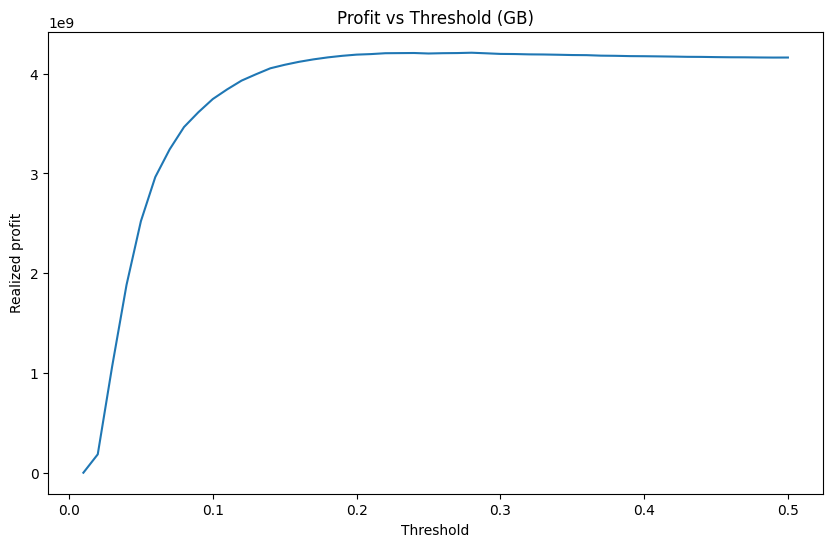

In [406]:
x = profit_table['thr']
y = profit_table['realized_profit']

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x, y)
ax.set_xlabel('Threshold')
ax.set_ylabel('Realized profit')
ax.set_title('Profit vs Threshold (GB)')
plt.show()

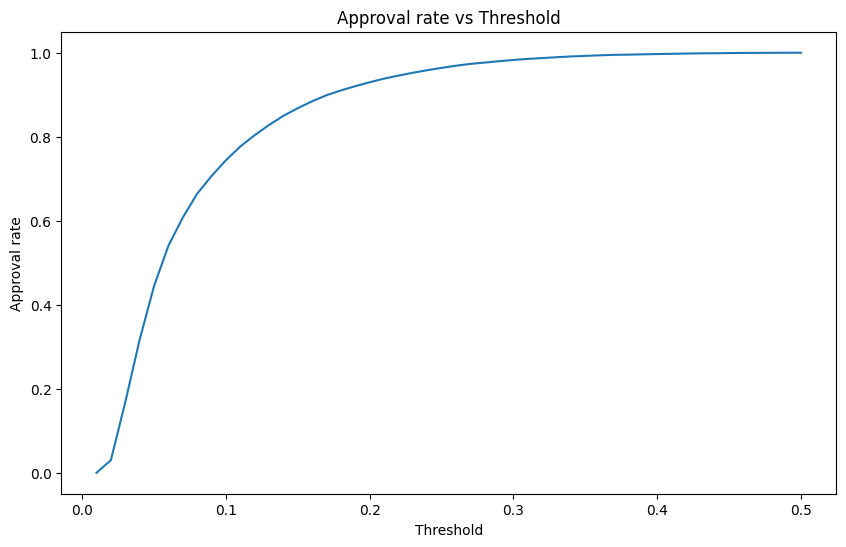

In [407]:
x = profit_table['thr']
y = profit_table['approval_rate']

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x,y)
ax.set_xlabel('Threshold')
ax.set_ylabel('Approval rate')
ax.set_title('Approval rate vs Threshold')
plt.show()

In [416]:
def profit_table(p, y_true, L, r=0.2, LGD=0.6, thresholds=np.linspace(0.01,0.5,50)):
    y_true = np.asarray(y_true)
    p = np.asarray(p)
    L = np.asarray(L)

    realized_profit = ((1-y_true)*(L*r)-y_true*(L*LGD))
    rows = []
    for t in thresholds:
        approve = (p<t)
        approval_rate = approve.mean()
        default_rate_approved = y_true[approve].mean() if approve.any() else np.nan
        realized_profit_policy = realized_profit[approve].sum()
        rows.append((t,approval_rate,default_rate_approved,realized_profit_policy))
    return pd.DataFrame(rows, columns=['thr','approval_rate','default_rate_approved','realized_profit'])

def best_under_constraints(df, min_approval=None, max_default=None):
    filtered = df.copy()
    if min_approval is not None:
        filtered = filtered[filtered['approval_rate']>=min_approval]
    if max_default is not None:
        filtered = filtered[filtered['default_rate_approved']<=max_default]
    return filtered.sort_values('realized_profit', ascending=False).head(1)

In [417]:
L = x_test['AMT_CREDIT'].values
df_lr = profit_table(proba_lr_unweighted, y_test.values, L)
df_gb = profit_table(proba_gb, y_test.values, L)

In [419]:
best_lr_A = best_under_constraints(df_lr, max_default=0.07)
best_gb_A = best_under_constraints(df_gb, max_default=0.07)
best_lr_A, best_gb_A

(     thr  approval_rate  default_rate_approved  realized_profit
 21  0.22       0.948722               0.069667     4.197461e+09,
      thr  approval_rate  default_rate_approved  realized_profit
 22  0.23       0.951933               0.069667     4.206557e+09)

In [421]:
best_lr_B = best_under_constraints(df_lr, min_approval=0.95)
best_gb_B = best_under_constraints(df_gb, min_approval=0.95)
best_lr_B, best_gb_B

(     thr  approval_rate  default_rate_approved  realized_profit
 23  0.24       0.960571               0.071876     4.197376e+09,
      thr  approval_rate  default_rate_approved  realized_profit
 27  0.28        0.97616               0.074143     4.210428e+09)

In [423]:
df_model

,AGE_YEARS,YEARS_EMPLOYED,EMPLOYED_ANOMALY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,EXT_SOURCE_MEAN,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_INCOME_TYPE_CLEAN,OCCUPATION_CLEAN,ORG_CLEAN,NAME_HOUSING_TYPE,TARGET
273229,41.364384,17.553425,0,112500.0,180000.0,9000.0,1.600000,0.080000,0.589569,2.0,State servant,Medicine staff,Medicine,House / apartment,0
243443,29.123288,1.835616,0,202500.0,432567.0,22779.0,2.136133,0.112489,0.411493,NaN,Commercial associate,Laborers,Military,House / apartment,0
90102,31.282192,7.758904,0,90000.0,203760.0,22072.5,2.264000,0.245250,0.330391,2.0,Working,Sales staff,Business Entity Type 3,House / apartment,1
37979,33.780822,4.865753,0,220500.0,180000.0,9000.0,0.816327,0.040816,0.456555,3.0,Commercial associate,Managers,Business Entity Type 3,House / apartment,0
130754,27.515068,1.380822,0,94500.0,239850.0,25830.0,2.538095,0.273333,0.331702,NaN,Working,Missing,School,House / apartment,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254155,57.142466,NaN,1,157500.0,104256.0,11074.5,0.661943,0.070314,0.538686,2.0,Pensioner,Missing,XNA,House / apartment,0
55086,58.635616,NaN,1,67500.0,246357.0,24129.0,3.649733,0.357467,0.744530,2.0,Pensioner,Missing,XNA,House / apartment,0
79181,56.391781,24.279452,0,202500.0,202500.0,10125.0,1.000000,0.050000,0.607216,2.0,Working,Accountants,Other_Org,House / apartment,0
13229,33.424658,4.449315,0,112500.0,180000.0,9000.0,1.600000,0.080000,0.663075,1.0,Commercial associate,Private service staff,Self-employed,House / apartment,0


In [424]:
df_model.columns

Index(['AGE_YEARS', 'YEARS_EMPLOYED', 'EMPLOYED_ANOMALY', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME',
       'EXT_SOURCE_MEAN', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'NAME_INCOME_TYPE_CLEAN', 'OCCUPATION_CLEAN', 'ORG_CLEAN',
       'NAME_HOUSING_TYPE', 'TARGET'],
      dtype='object')

## Final Evaluation

In [425]:
test_df['AGE_YEARS'] = -test_df['DAYS_BIRTH'] / 365
test_df['EMPLOYED_ANOMALY'] = (test_df['DAYS_EMPLOYED'] == 365243).astype(int)
test_df.loc[test_df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan
test_df['YEARS_EMPLOYED'] = -test_df['DAYS_EMPLOYED'] / 365
test_df['CREDIT_TO_INCOME'] = test_df['AMT_CREDIT'] / test_df['AMT_INCOME_TOTAL']
test_df['ANNUITY_TO_INCOME'] = test_df['AMT_ANNUITY'] / test_df['AMT_INCOME_TOTAL']
test_df['EXT_SOURCE_MEAN'] = test_df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

In [426]:
test_df['NAME_INCOME_TYPE_CLEAN'] = test_df['NAME_INCOME_TYPE'].replace({'Businessman':'Other','Student':'Other','Maternity leave':'Other','Unemployed':'Other'})

In [428]:
train_df['OCCUPATION_TYPE']

273229           Medicine staff
243443                 Laborers
90102               Sales staff
37979                  Managers
130754                      NaN
                  ...          
254155                      NaN
55086                       NaN
79181               Accountants
13229     Private service staff
70610                       NaN
Name: OCCUPATION_TYPE, Length: 246008, dtype: object

In [429]:
baseline = train_df[target].mean()

occ_stats = train_df.assign(OCC=train_df['OCCUPATION_TYPE'].fillna('Missing')).groupby('OCC')[target].agg(['mean','count'])
keep_occ = set(occ_stats.index[occ_stats['count']>=2000]) | {'Missing'}
keep_occ = keep_occ.union(occ_stats.index[(occ_stats['count']>=1000) & (occ_stats['mean'] >= baseline + 0.03)])

org_stats = train_df.assign(ORG=train_df['ORGANIZATION_TYPE'].fillna('Missing')).groupby('ORG')[target].agg(['mean','count'])
keep_org = set(org_stats.index[org_stats['count']>=2000]) | {'Missing'}
keep_org = keep_org.union(org_stats.index[(org_stats['count']>=1000) & ((org_stats['mean']>= baseline + 0.03)|(org_stats['mean']<= baseline-0.02))])

occ = test_df['OCCUPATION_TYPE'].fillna('Missing')
test_df['OCCUPATION_CLEAN'] = np.where(occ.isin(keep_occ), occ, 'Other')

org = test_df['ORGANIZATION_TYPE'].fillna('Missing')
test_df['ORG_CLEAN'] = np.where(org.isin(keep_org), org, 'Other')

In [430]:
df_model_cols = ['AGE_YEARS', 'YEARS_EMPLOYED', 'EMPLOYED_ANOMALY', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME',
       'EXT_SOURCE_MEAN', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'NAME_INCOME_TYPE_CLEAN', 'OCCUPATION_CLEAN', 'ORG_CLEAN',
       'NAME_HOUSING_TYPE', 'TARGET']

In [431]:
test_df_model = test_df[df_model_cols].copy()

In [436]:
x_test_final = test_df_model.drop(columns=[target])
y_test_final = test_df_model[target]

test_proba = clf_gb.predict_proba(x_test_final)[:,1]

In [439]:
thr = 0.23
L = x_test_final['AMT_CREDIT'].values
p = test_proba

approve = (p < thr)
print('Profit threshold:', thr)
print('Approval rate:', approve.mean())

print('Default rate among approved:', y_test_final.values[approve].mean())
expected_profit = approve * ((1-p) * (L * r) - p * (L * LGD))
print('Total expected profit:', expected_profit.sum())
print('Avg expected profit per approved loan:', expected_profit[approved_idx].mean())

Profit threshold: 0.23
Approval rate: 0.9520673788270491
Default rate among approved: 0.07008795149859107
Total expected profit: 5196791089.372898
Avg expected profit per approved loan: 88750.59498544784


In [438]:
y_true = y_test_final.values
realized_profit = approve * ((1-y_true) * (L*r) - y_true * (L * LGD))

print('Total realized profit:', realized_profit.sum())
print('Avg realized profit per approved loan:', realized_profit[approved_idx].mean())

Total realized profit: 5220256871.7
Avg realized profit per approved loan: 89151.34269831784
